# Exercises - Forward Rates

#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$

This exercise builds on the bootstrapped spot curve to calculate forward rates.

### Data

Use the bootstrapped spot curve from the data file:
`data/treasury_quotes_2025-11-28.xlsx`, sheet `selected quotes`

In [11]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel('../Data/treasury_quotes_2025-11-28.xlsx', sheet_name='selected quotes')
df

,KYTREASNO,type,quote date,issue date,maturity date,ttm,accrual fraction,cpn rate,bid,ask,price,accrued int,dirty price,ytm,total size,duration
0,208227,note,2025-11-28,2024-05-31,2026-05-31,0.503765,0.989071,4.875,100.521406,100.531220,100.526313,2.410861,102.937174,0.038263,7.142500e+10,0.492305
1,208316,note,2025-11-28,2024-11-30,2026-11-30,1.004791,0.989071,4.250,100.572266,100.591764,100.582015,2.101776,102.683791,0.036575,7.314900e+10,0.974601
2,208399,note,2025-11-28,2025-05-31,2027-05-31,1.503080,0.989071,3.875,100.453125,100.472656,100.462891,1.916325,102.379216,0.035621,7.844000e+10,1.448055
3,208484,note,2025-11-28,2025-11-30,2027-11-30,2.004107,0.000000,3.375,99.765625,99.769531,99.767578,0.000000,99.767578,0.034889,NaN,1.956136
4,208058,note,2025-11-28,2023-05-31,2028-05-31,2.505133,0.989071,3.625,100.312500,100.332031,100.322266,1.792691,102.114957,0.034901,4.936300e+10,2.376588
5,208145,note,2025-11-28,2023-11-30,2028-11-30,3.006160,0.989071,4.375,102.437500,102.472656,102.455078,2.163593,104.618671,0.035065,5.553400e+10,2.794544
6,208229,note,2025-11-28,2024-05-31,2029-05-31,3.504449,0.989071,4.500,103.171875,103.207031,103.189453,2.225410,105.414863,0.035258,7.415600e+10,3.218036
7,208318,note,2025-11-28,2024-11-30,2029-11-30,4.005476,0.989071,4.125,102.078125,102.132812,102.105469,2.039959,104.145428,0.035564,7.476100e+10,3.665596
8,208401,note,2025-11-28,2025-05-31,2030-05-31,4.503765,0.989071,4.000,101.730469,101.785156,101.757812,1.978142,103.735955,0.035754,7.958200e+10,4.092696
9,208486,note,2025-11-28,2025-11-30,2030-11-30,5.004791,0.000000,3.500,99.546875,99.554688,99.550781,0.000000,99.550781,0.035953,NaN,4.637183


***

### 1.1. Bootstrap the Spot Curve

Using the selected quotes (approximately 6-month intervals), bootstrap the spot curve.

Report for maturity T=5:
* The discount factor
* The semiannually-compounded spot rate
* The continuously-compounded spot rate

Round to 4 decimal places.

In [7]:
df_sel = df.copy()

# Convert coupon from percent to decimal
df_sel["coupon"] = df_sel["cpn rate"] / 100

# Round maturities to nearest 0.5 years
df_sel["T"] = (df_sel["ttm"] * 2).round() / 2

# Sort by maturity
df_sel = df_sel.sort_values("T").reset_index(drop=True)

# Bootstrap discount factors
discount_factors = {}

for _, row in df_sel.iterrows():
    T = row["T"]
    price = row["price"]
    coupon = row["coupon"]
    
    c = 100 * coupon / 2        # semiannual coupon
    n = int(2 * T)              # number of coupon periods
    
    # PV of known earlier coupons
    pv_known = 0.0
    for i in range(1, n):
        t_i = i * 0.5
        pv_known += c * discount_factors[t_i]
    
    # Solve for discount factor at maturity
    z_T = (price - pv_known) / (100 + c)
    discount_factors[T] = z_T

# Convert to Series
z_boot = pd.Series(discount_factors).sort_index()

T = 5.0
z_5 = z_boot[T]

# Semiannually compounded spot rate
r_sa_5 = 2 * (z_5 ** (-1 / (2 * T)) - 1)

# Continuously compounded spot rate
r_cc_5 = -np.log(z_5) / T

print("Bootstrap results at T = 5 years")
print(f"Discount Factor: {z_5:.4f}")
print(f"Semiannual Spot Rate: {r_sa_5:.4f}")
print(f"Continuous Spot Rate: {r_cc_5:.4f}")

Bootstrap results at T = 5 years
Discount Factor: 0.8365
Semiannual Spot Rate: 0.0360
Continuous Spot Rate: 0.0357


### 1.2. Forward Discount Factors

Using the spot curve, calculate the 6-month forward discount factors:

$$F(0, T, T+0.5) = \frac{Z(0, T+0.5)}{Z(0, T)}$$

Report a table with columns:
* `T` (starting maturity)
* `forward discount` 
* `forward rate (semi-annual)`
* `forward rate (continuous)`

For T=5 to T=5.5, report all three values rounded to 4 decimal places.

In [9]:
rows = []

for T in z_boot.index[:-1]:
    T_next = T + 0.5
    
    if T_next not in z_boot.index:
        continue
    
    F = z_boot[T_next] / z_boot[T]
    
    # Forward rates
    r_sa = 2 * (F ** -1 - 1)
    r_cc = -2 * np.log(F)
    
    rows.append({
        "T": T,
        "forward discount": F,
        "forward rate (semi-annual)": r_sa,
        "forward rate (continuous)": r_cc
    })

forward_df = pd.DataFrame(rows)

forward_5 = forward_df[forward_df["T"] == 5.0].round(4)
forward_5

,T,forward discount,forward rate (semi-annual),forward rate (continuous)
9,5.0,0.9787,0.0435,0.0431


### 1.3. Forward Curve Analysis

1. Plot the spot rate curve and the 6-month forward rate curve on the same axes.

2. For which maturity interval $(T_1, T_2)$ is the forward rate highest?

3. At maturities where the forward rate is above the spot rate, what does this imply about the slope of the spot curve?

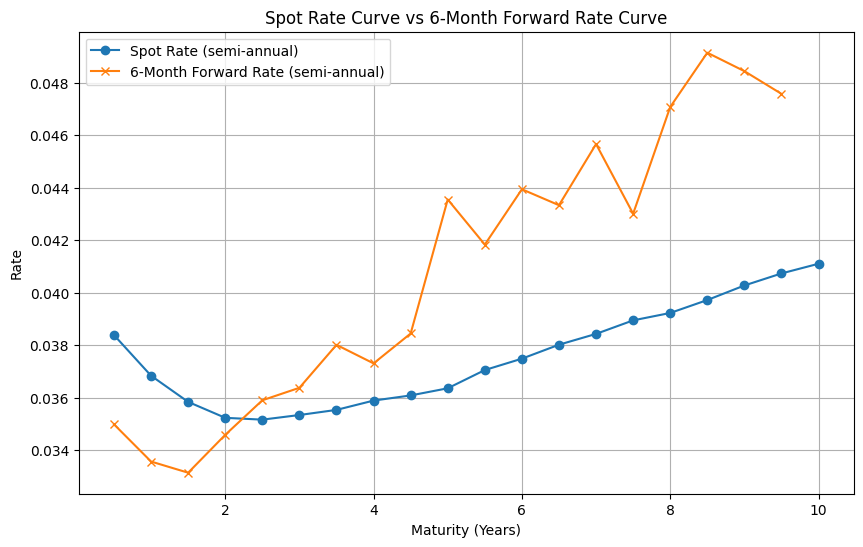

In [13]:
spot_df = pd.DataFrame({
    "T": z_boot.index,
    "spot rate (semi-annual)": (z_boot.values ** (-1/z_boot.index) - 1),
    "spot rate (continuous)": -np.log(z_boot.values)/z_boot.index
})

plt.figure(figsize=(10,6))

# Spot rates
plt.plot(spot_df["T"], spot_df["spot rate (semi-annual)"], label="Spot Rate (semi-annual)", marker='o')

# Forward rates
plt.plot(forward_df["T"], forward_df["forward rate (semi-annual)"], label="6-Month Forward Rate (semi-annual)", marker='x')

plt.xlabel("Maturity (Years)")
plt.ylabel("Rate")
plt.title("Spot Rate Curve vs 6-Month Forward Rate Curve")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
max_idx = forward_df["forward rate (semi-annual)"].idxmax()
T1 = forward_df.loc[max_idx, "T"]
T2 = T1 + 0.5
highest_forward_rate = forward_df.loc[max_idx, "forward rate (semi-annual)"]

print(f"Highest forward rate is {highest_forward_rate:.4f} for interval T = {T1} to {T2}")
print()


Highest forward rate is 0.0491 for interval T = 8.5 to 9.0



If the forward rate is higher than the spot rate at a given maturity, it means that borrowing or lending in the future is expected to be more expensive than today. This implies that the spot rate curve is upward sloping at that interval. In other words, interest rates are increasing with maturity. It reflects market expectations of rising rates in the future.

***